In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
bars_baseline = [0]*11
bars_ours = [0]*11

for p in Path('trajs/multi/baseline_for_gemini25pro').glob('*.json'):
    with p.open() as f:
        d = json.load(f)
    bars_baseline[d['metrics']['tot_step']//10] += 1

for p in Path('trajs/multi/gpt5mini_for_gemini25pro').glob('*.json'):
    with p.open() as f:
        d = json.load(f)
    bars_ours[d['metrics']['tot_step']//10] += 1

In [4]:
bars_ours

[1, 35, 57, 69, 51, 27, 11, 13, 5, 4, 26]

In [5]:
bars_baseline

[2, 23, 40, 47, 32, 28, 24, 16, 12, 9, 66]

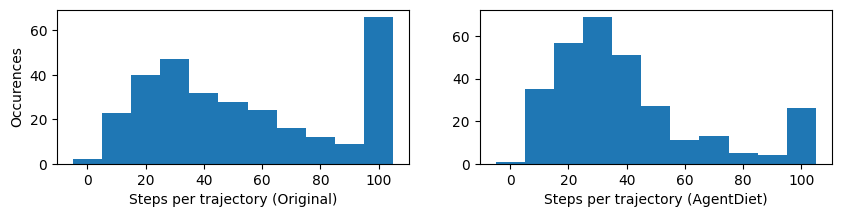

In [20]:
fig, (ax0, ax1) = plt.subplots(1, 2, sharey=False, figsize=(10, 2))

xs = list(range(0, 110, 10))
ax0.bar(xs, bars_baseline, width=10)
ax0.set_xlabel('Steps per trajectory (Original)')
ax0.set_ylabel('Occurences')
ax1.bar(xs, bars_ours, width=10)
ax1.set_xlabel('Steps per trajectory (AgentDiet)')

plt.savefig('evaluation-steps.pdf', bbox_inches='tight')
plt.show()